# Huấn luyện CNN nhận dạng chữ số MNIST bằng PyTorch

Notebook này tải MNIST, huấn luyện CNN trong 10 epochs, đánh giá trên tập test và lưu checkpoint để ứng dụng `app.py` sử dụng.

In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from model import MNISTCNN, MNIST_MEAN, MNIST_STD, count_trainable_parameters

SEED = 42
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
DATA_DIR = Path('data')
CHECKPOINT_PATH = Path('models/mnist_cnn.pth')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị huấn luyện: {device}')

PyTorch: 2.14.0
Thiết bị huấn luyện: mps


## 1. Chuẩn bị dữ liệu

Ảnh được chuyển thành tensor và chuẩn hóa bằng mean `0.1307`, standard deviation `0.3081` của MNIST.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

train_dataset = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    pin_memory=device.type == 'cuda', generator=loader_generator,
)
test_loader = DataLoader(
    test_dataset, batch_size=512, shuffle=False, num_workers=0,
    pin_memory=device.type == 'cuda',
)

print(f'Tập train: {len(train_dataset):,} ảnh')
print(f'Tập test:  {len(test_dataset):,} ảnh')

Tập train: 60,000 ảnh
Tập test:  10,000 ảnh


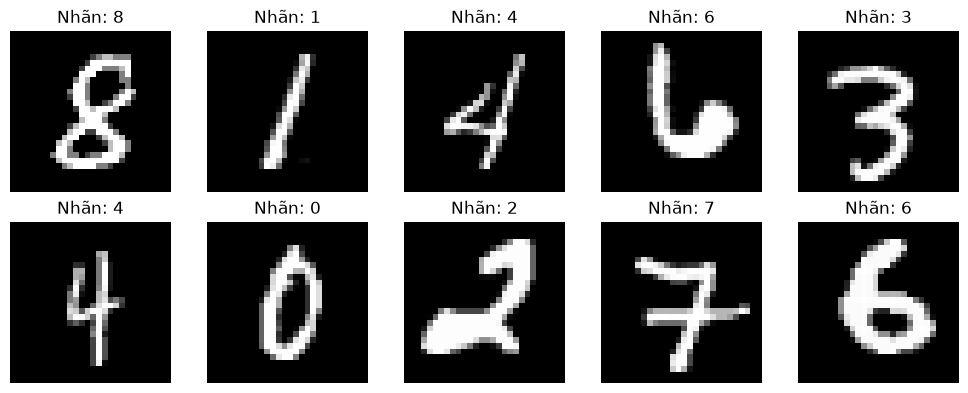

In [3]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for image, label, axis in zip(images[:10], labels[:10], axes.flat):
    display_image = image.squeeze().numpy() * MNIST_STD[0] + MNIST_MEAN[0]
    axis.imshow(display_image, cmap='gray')
    axis.set_title(f'Nhãn: {label.item()}')
    axis.axis('off')
plt.tight_layout()
plt.show()

## 2. Khởi tạo mô hình và hàm huấn luyện

In [4]:
model = MNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print(f'Số tham số có thể huấn luyện: {count_trainable_parameters(model):,}')

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Số tham số có thể huấn luyện: 421,642


In [5]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_labels in data_loader:
        batch_images = batch_images.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(batch_images)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        batch_size = batch_labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total += batch_size

    return running_loss / total, correct / total


@torch.inference_mode()
def evaluate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_labels in data_loader:
        batch_images = batch_images.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)
        logits = model(batch_images)
        loss = criterion(logits, batch_labels)

        batch_size = batch_labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total += batch_size

    return running_loss / total, correct / total

## 3. Huấn luyện trong 10 epochs

In [6]:
history = {'train_loss': [], 'train_accuracy': [], 'test_loss': [], 'test_accuracy': []}
training_started = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    epoch_started = time.perf_counter()
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_accuracy'].append(test_accuracy)

    elapsed = time.perf_counter() - epoch_started
    print(
        f'Epoch {epoch:02d}/{EPOCHS} | {elapsed:6.1f}s | '
        f'train loss {train_loss:.4f} | train acc {train_accuracy:.2%} | '
        f'test loss {test_loss:.4f} | test acc {test_accuracy:.2%}'
    )

print(f'Tổng thời gian huấn luyện: {(time.perf_counter() - training_started) / 60:.1f} phút')

Epoch 01/10 |    5.0s | train loss 0.1972 | train acc 93.98% | test loss 0.0432 | test acc 98.67%


Epoch 02/10 |    4.6s | train loss 0.0548 | train acc 98.32% | test loss 0.0378 | test acc 98.66%


Epoch 03/10 |    4.6s | train loss 0.0395 | train acc 98.78% | test loss 0.0328 | test acc 98.96%


Epoch 04/10 |    4.6s | train loss 0.0315 | train acc 99.00% | test loss 0.0252 | test acc 99.21%


Epoch 05/10 |    4.7s | train loss 0.0254 | train acc 99.22% | test loss 0.0305 | test acc 98.94%


Epoch 06/10 |    4.6s | train loss 0.0223 | train acc 99.26% | test loss 0.0305 | test acc 99.04%


Epoch 07/10 |    4.7s | train loss 0.0170 | train acc 99.46% | test loss 0.0273 | test acc 99.06%


Epoch 08/10 |    4.7s | train loss 0.0159 | train acc 99.48% | test loss 0.0270 | test acc 99.15%


Epoch 09/10 |    4.6s | train loss 0.0141 | train acc 99.47% | test loss 0.0238 | test acc 99.35%


Epoch 10/10 |    4.6s | train loss 0.0119 | train acc 99.60% | test loss 0.0311 | test acc 99.14%
Tổng thời gian huấn luyện: 0.8 phút


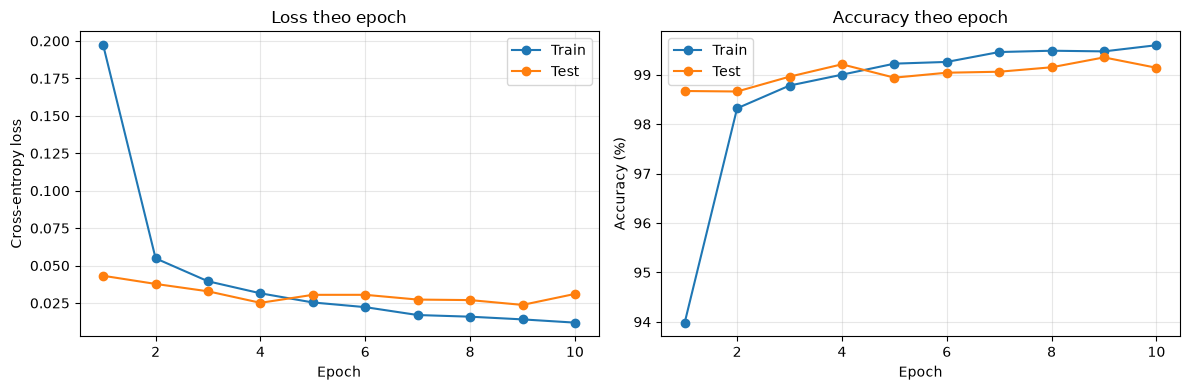

In [7]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history['train_loss'], marker='o', label='Train')
axes[0].plot(epochs, history['test_loss'], marker='o', label='Test')
axes[0].set(title='Loss theo epoch', xlabel='Epoch', ylabel='Cross-entropy loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, np.array(history['train_accuracy']) * 100, marker='o', label='Train')
axes[1].plot(epochs, np.array(history['test_accuracy']) * 100, marker='o', label='Test')
axes[1].set(title='Accuracy theo epoch', xlabel='Epoch', ylabel='Accuracy (%)')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Đánh giá, xem dự đoán mẫu và lưu weights

In [8]:
final_test_loss, final_test_accuracy = evaluate(model, test_loader, criterion, device)
print(f'Test loss cuối: {final_test_loss:.4f}')
print(f'Test accuracy cuối: {final_test_accuracy:.2%}')
if final_test_accuracy < 0.98:
    print('Cảnh báo: accuracy chưa đạt mục tiêu 98%. Có thể chạy lại notebook để kiểm tra.')

Test loss cuối: 0.0311
Test accuracy cuối: 99.14%


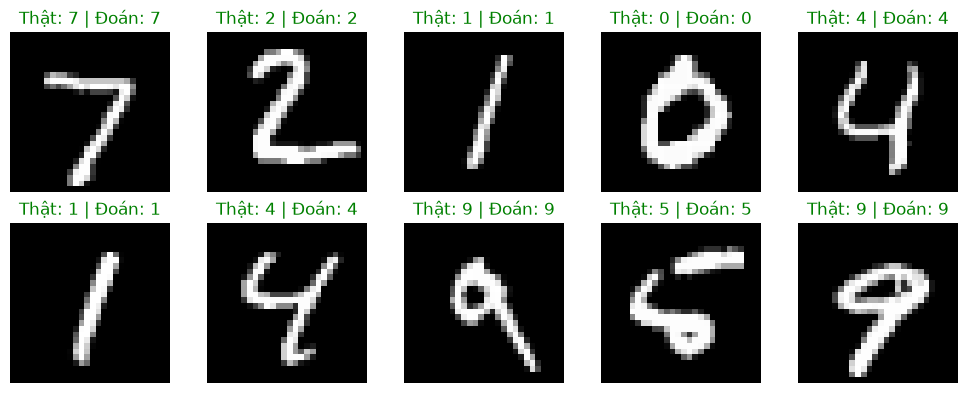

In [9]:
sample_images, sample_labels = next(iter(test_loader))
with torch.inference_mode():
    sample_logits = model(sample_images[:10].to(device))
    sample_predictions = sample_logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for image, true_label, prediction, axis in zip(
    sample_images[:10], sample_labels[:10], sample_predictions, axes.flat
):
    display_image = image.squeeze().numpy() * MNIST_STD[0] + MNIST_MEAN[0]
    axis.imshow(display_image, cmap='gray')
    color = 'green' if prediction.item() == true_label.item() else 'red'
    axis.set_title(f'Thật: {true_label.item()} | Đoán: {prediction.item()}', color=color)
    axis.axis('off')
plt.tight_layout()
plt.show()

In [10]:
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
cpu_state_dict = {name: tensor.detach().cpu() for name, tensor in model.state_dict().items()}
checkpoint = {
    'model_state_dict': cpu_state_dict,
    'epochs': EPOCHS,
    'test_accuracy': final_test_accuracy,
    'normalization': {'mean': MNIST_MEAN, 'std': MNIST_STD},
    'class_names': [str(digit) for digit in range(10)],
}
torch.save(checkpoint, CHECKPOINT_PATH)
print(f'Đã lưu checkpoint: {CHECKPOINT_PATH.resolve()}')
print(f'Kích thước: {CHECKPOINT_PATH.stat().st_size / (1024 ** 2):.2f} MB')

Đã lưu checkpoint: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/MNIST_Demo/models/mnist_cnn.pth
Kích thước: 1.61 MB


## 5. Kiểm chứng checkpoint

Nạp weights vào một mô hình mới trên CPU và xác nhận logits giống mô hình vừa huấn luyện.

In [11]:
model.eval()
reference_images = sample_images[:16]
with torch.inference_mode():
    original_logits = model(reference_images.to(device)).cpu()

saved_checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=True)
reloaded_model = MNISTCNN()
reloaded_model.load_state_dict(saved_checkpoint['model_state_dict'])
reloaded_model.eval()
with torch.inference_mode():
    reloaded_logits = reloaded_model(reference_images)

torch.testing.assert_close(original_logits, reloaded_logits, rtol=1e-4, atol=1e-5)
assert saved_checkpoint['epochs'] == EPOCHS
assert saved_checkpoint['test_accuracy'] >= 0.98
print('Kiểm chứng thành công: checkpoint nạp lại đúng và accuracy >= 98%.')

Kiểm chứng thành công: checkpoint nạp lại đúng và accuracy >= 98%.
